### <font color=skyblue>Prepare and observe the AT&T face image data before training</font>

- Original faces
- Eignefaces
- Reconstructed faces from Eigenfaces

<font color=red>注意：之後將分別使用原始影像與特徵臉(Eigenfaces)進行人臉識別訓練，並比較兩者的效果。</font>

<hr>

<font color=yellow>Load and check the image data</font>

人臉影像資料的儲存格式沒有固定規則，通常會根據不同的應用需求和資料來源而有所不同。必須先觀察資料的特性，來決定如何處理和使用影像資料。

In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv('data/face_data.csv')
n_persons = df['target'].nunique() 
X = np.array(df.drop('target', axis=1)) # 400 x 4096
y = np.array(df['target'])

print(f"Number of persons: {n_persons}")
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Number of persons: 40
Shape of X: (400, 4096)
Shape of y: (400,)


<font color=yellow>Display the image data</font>

常見以蒙太奇(montage)方式呈現影像資料，將多張影像排列在同一個畫面中，方便觀察影像資料的特性。

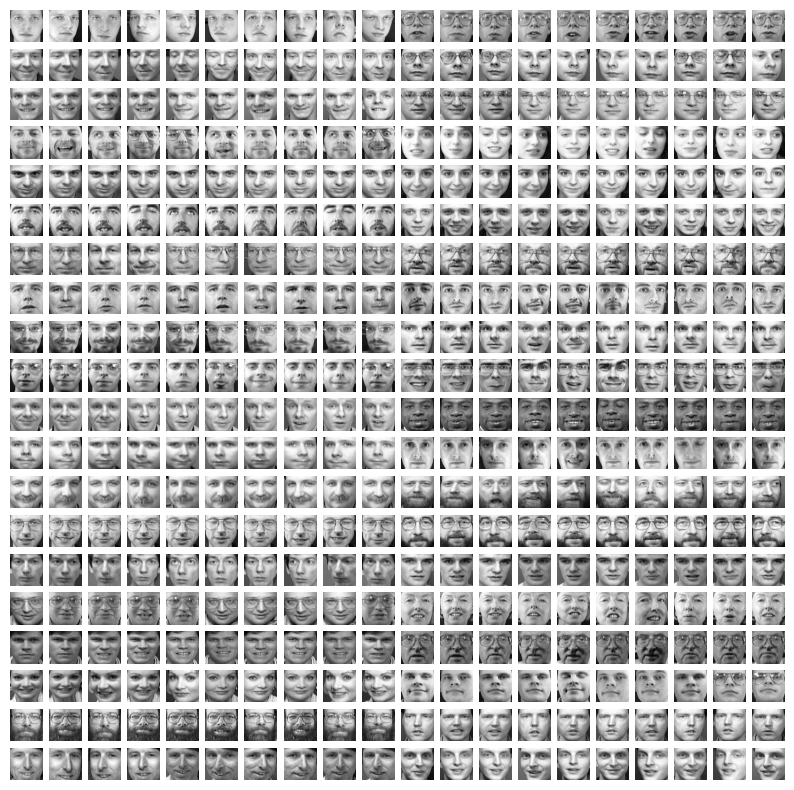

In [2]:
# display the images in X in a grid of 20 x 20
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for i in range(400):
    plt.subplot(20, 20, i + 1)
    plt.imshow(X[i].reshape(64, 64), cmap='gray')
    plt.axis('off')
plt.show()

<font color=yellow>Display the images in a montage frame</font>

以下是較有效率的方式。

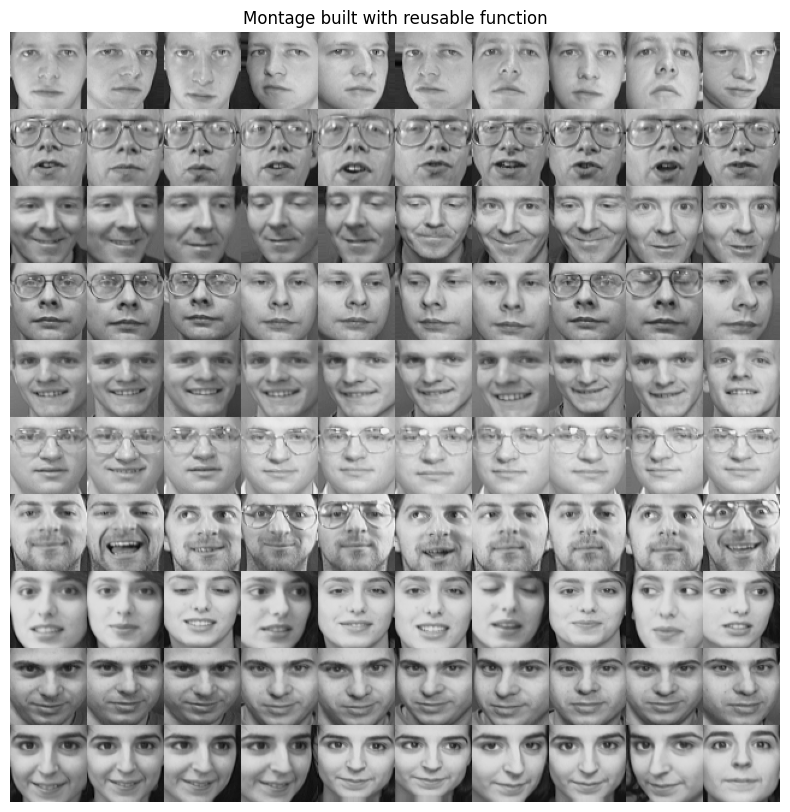

In [3]:
# Generalize into a Reusable Function
def build_montage(X, img_h, img_w, m, n):
    """
    Rearrange a flattened image array X (N x (img_h*img_w)) into an
    m x n montage matrix of shape (m*img_h, n*img_w).

    Parameters
    ----------
    X : np.ndarray
        Array of shape (N, img_h*img_w) containing flattened images.
    img_h, img_w : int
        Height and width of each individual image.
    m, n : int
        Number of rows and columns in the montage grid.

    Returns
    -------
    montage : np.ndarray
        2D array of shape (m*img_h, n*img_w) representing the montage.
    """
    assert m * n <= X.shape[0], f"m*n ({m*n}) exceeds number of images in X ({X.shape[0]})"
    grid = X[:m * n].reshape(m, n, img_h, img_w)
    montage = grid.transpose(0, 2, 1, 3).reshape(m * img_h, n * img_w)
    return montage

# Example usage:
img_h, img_w = 64, 64
m, n = 10, 10
montage_2 = build_montage(X, img_h, img_w, m, n)
plt.figure(figsize=(10, 10))
plt.imshow(montage_2, cmap='gray')
plt.axis('off')
plt.title("Montage built with reusable function")
plt.show()


<font color=yellow>從每個人的 10 張照片中，隨機選擇 1 張照片，並將這些照片顯示在一個 4 x 10 的網格中</font>

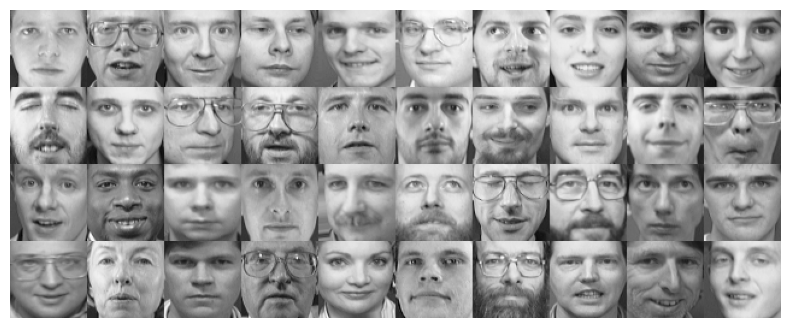

In [13]:
# 從每個人的 10 張照片中，隨機選擇 1 張照片，並將這些照片顯示在一個 4 x 10 的網格中
import matplotlib.pyplot as plt

# 隨機選擇 1 張照片
selected_images = []
for i in range(n_persons):
    idx = np.random.choice(np.where(y == i)[0])
    selected_images.append(X[idx])


# 顯示在一個 4 x 10 的網格中
# use build_montage function to create a montage of the selected images
montage_selected = build_montage(np.array(selected_images), img_h, img_w, 4, 10)
plt.figure(figsize=(10, 4))
plt.imshow(montage_selected, cmap='gray')
plt.axis('off')
plt.show()
# fig, axes = plt.subplots(4, 10, figsize=(10, 4))
# for i in range(4):
#     for j in range(10):
#         axes[i, j].imshow(selected_images[i * 10 + j].reshape(img_h, img_w), cmap='gray')
#         axes[i, j].axis('off')
# plt.show()

<font color=yellow>Eigenfaces</font>

Eigenfaces 指的是從人臉影像資料中提取出來的特徵臉，這些特徵臉是從原始影像資料透過主成分分析（PCA）方法計算出來的主成分 Z，但不具備影像的直觀意義。為了更好地理解這些主成分，我們可以將它們轉換回原始影像空間，呈現出近似重建的原始影像（X_approx）。這個過程可以幫助我們理解主成分分析（PCA）如何捕捉影像資料的主要特徵，並且在降低維度的同時保留重要資訊。

<font color=yellow>Derive the eignevectors of the face images</font>

The eigenfaces are the eigenvectors of the covariance matrix of the face images. 

注意： eigenvectors 的維度與人臉影像相同，因此可以觀察出內涵的影像訊息。

Eigenfaces shape: (100, 4096)
Explained variance ratio (first 10): [0.23812729 0.13993971 0.07968614 0.04998331 0.03609848 0.03156939
 0.02426832 0.02036398 0.01958114 0.01672122]
Total explained variance (first 100 components): 0.9350


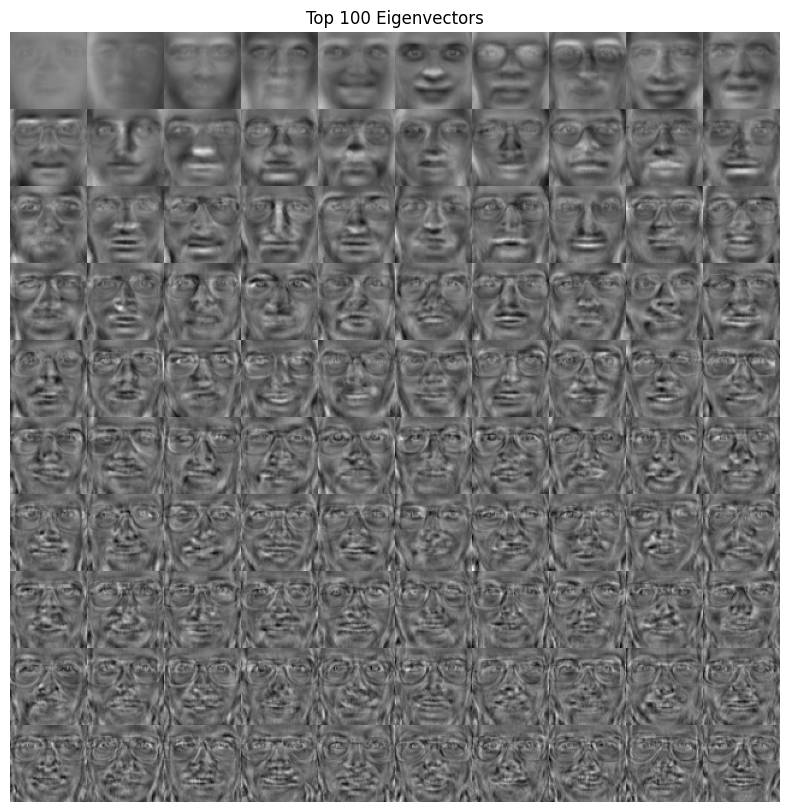

In [21]:
# derive and display the eigenvectors of the image data using PCA
from sklearn.decomposition import PCA

n_components = 100  # number of eigenfaces to compute

pca = PCA(n_components=n_components, whiten=True, random_state=42)
pca.fit(X)

eigen_vec = pca.components_  # shape: (n_components, img_h*img_w)

print(f"Eigenfaces shape: {eigen_vec.shape}")
print(f"Explained variance ratio (first 10): {pca.explained_variance_ratio_[:10]}")
print(f"Total explained variance (first {n_components} components): {pca.explained_variance_ratio_.sum():.4f}")

# Display the top eigenfaces using the montage function
n_display = n_components  # display first 25 eigenfaces (5x5 grid)
m, n = 10, 10
montage_eigen_vec = build_montage(eigen_vec, img_h, img_w, m, n)

plt.figure(figsize=(10, 10))
plt.imshow(montage_eigen_vec, cmap='gray')
plt.axis('off')
plt.title(f"Top {n_display} Eigenvectors")
plt.show()

<font color=yellow>Derive the principal components and transform back to the original space</font>

Eigenfaces 指維度降低後的主成分（Z），不具備影像的直觀意義。為了更好地理解這些主成分，我們可以將它們轉換回原始影像空間，呈現出近似重建的原始影像（X_approx）。這個過程可以幫助我們理解主成分分析（PCA）如何捕捉影像資料的主要特徵，並且在降低維度的同時保留重要資訊。

<font color=red>注意：最好試著調整 n_components 的值，觀察近似重建的影像與原始影像的差異，這有助於理解 PCA 的效果以及選擇適當的主成分數量。</font>

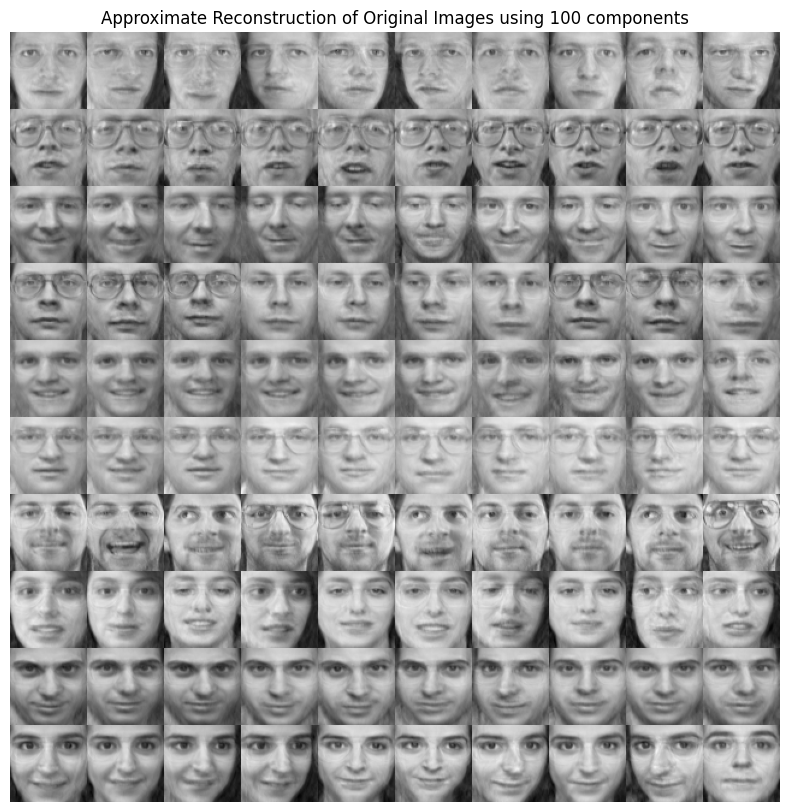

In [24]:
Z = pca.transform(X)  # principal components of the original images, shape: (n_samples, n_components)
X_approx = pca.inverse_transform(Z) # reconstruct the original images from the principal components

# Display the approximate reconstruction of the original images using the montage function
montage_approx = build_montage(X_approx, img_h, img_w, m, n)
plt.figure(figsize=(10, 10))
plt.imshow(montage_approx, cmap='gray')
plt.axis('off')
plt.title('Approximate Reconstruction of Original Images using {} components'.format(n_components))
plt.show()